# Moderator for Generative AI Content — Moderation Workbench

---

Welcome to the moderation workbench for the Moderator for Generative AI Content lab. Content moderation identifies and filters toxic, harmful, or personally identifiable content. Filtering happens before content reaches downstream systems or end users.

In this notebook, you use the AWS SDK for Python (Boto3) to call four managed AWS services on the same provided sample text and images:

1. **Amazon Comprehend** — text moderation, including toxicity + personally identifiable information (PII)
2. **Amazon Rekognition** — image moderation with `DetectModerationLabels`
3. **Amazon Nova 2 Lite on Amazon Bedrock** — multimodal large language model (LLM) moderation, including image + reasoning
4. **Amazon Bedrock Guardrails** — a managed content policy across text and image modalities

This comparison reveals the trade-offs between a purpose-built classifier, a multimodal foundation model, and a managed policy engine, so you can choose the right combination for a production pipeline.

---

## Setup

The next code cell defines the AWS clients and configuration values used throughout this notebook. Paste two values before you run the code cell:

- `IMAGE_BUCKET` — the Amazon S3 bucket that holds the provided sample images (copy the value from the `IMAGE_BUCKET` AWS CloudFormation stack output)
- `GUARDRAIL_ID` — the identifier for the Amazon Bedrock guardrail that you created in an earlier step in the Practice section (copy the value from the Amazon Bedrock console)

Replace each `<REPLACE_ME>` placeholder with the corresponding value, and then run the code cell.

In [1]:
import base64
import io
import json

import boto3

REGION = "us-east-1"
MODEL_ID = "us.amazon.nova-2-lite-v1:0"

# Paste the IMAGE_BUCKET S3 bucket value from the CloudFormation stack Outputs tab.
IMAGE_BUCKET = "moderator-gen-ai-lab-866688d0"

# Paste your guardrail ID from the Amazon Bedrock console.
GUARDRAIL_ID = "pop6n2nfuzjg"
GUARDRAIL_VERSION = "DRAFT"

s3 = boto3.client("s3", region_name=REGION)
comprehend = boto3.client("comprehend", region_name=REGION)
rekognition = boto3.client("rekognition", region_name=REGION)
bedrock_runtime = boto3.client("bedrock-runtime", region_name=REGION)

print(f"IMAGE_BUCKET = {IMAGE_BUCKET}")
print(f"MODEL_ID     = {MODEL_ID}")

IMAGE_BUCKET = moderator-gen-ai-lab-866688d0
MODEL_ID     = us.amazon.nova-2-lite-v1:0


### Load sample images

The S3 bucket for this practice solution contains nine sample images: five safe images and four flagged images for moderation. By using consistent inputs, you can compare how each moderation approach handles the same content. The next code cell loads a safe image and a flagged image from the S3 bucket, and the code displays the images so that you can see the content each service moderates.

safe/safe_01_wildlife.jpg (177538 bytes)


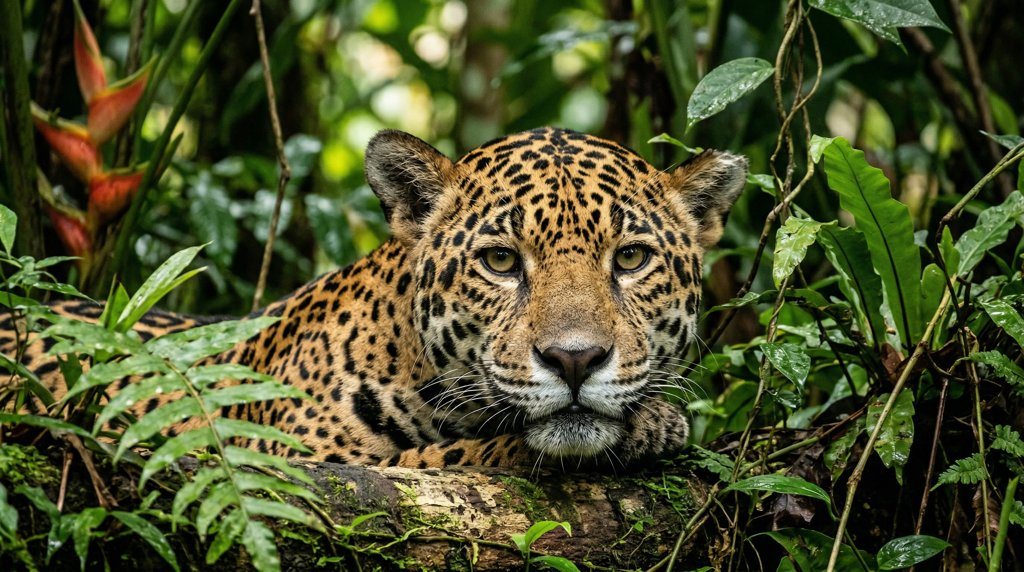

flagged/flag_04_weapon.jpg (36036 bytes)


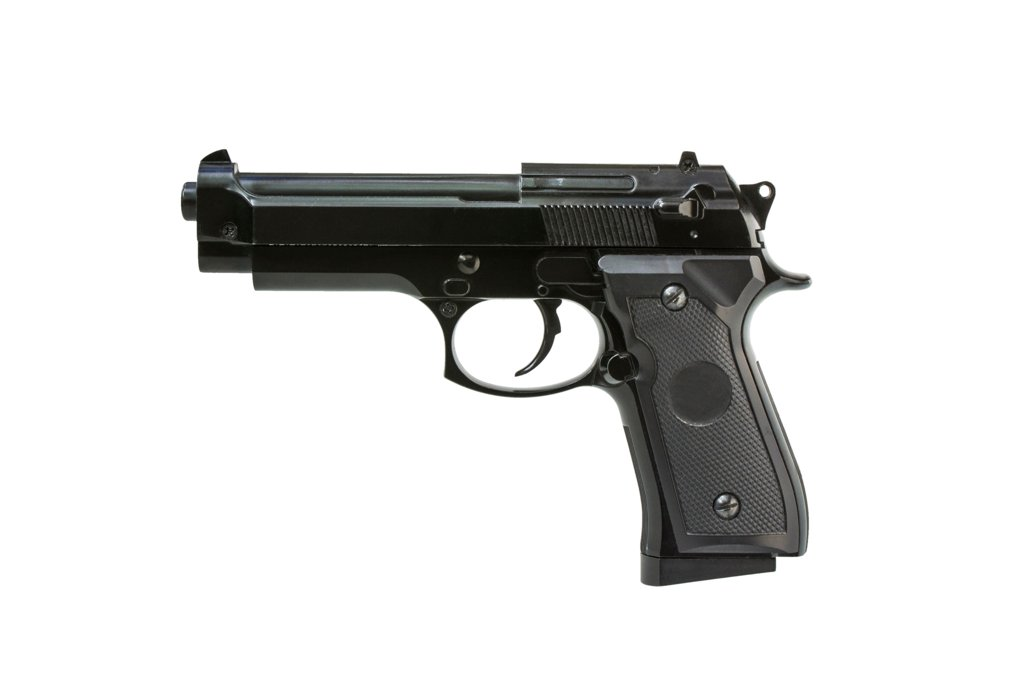

In [2]:
from IPython.display import Image, display


def load_image_bytes(key):
    return s3.get_object(Bucket=IMAGE_BUCKET, Key=f"images/{key}")["Body"].read()


SAFE_IMAGE = "safe/safe_01_wildlife.jpg"
FLAGGED_IMAGE = "flagged/flag_04_weapon.jpg"

safe_bytes = load_image_bytes(SAFE_IMAGE)
flagged_bytes = load_image_bytes(FLAGGED_IMAGE)

print(f"{SAFE_IMAGE} ({len(safe_bytes)} bytes)")
display(Image(data=safe_bytes, format="jpeg", width=320))
print(f"{FLAGGED_IMAGE} ({len(flagged_bytes)} bytes)")
display(Image(data=flagged_bytes, format="jpeg", width=320))

## 1. Amazon Comprehend — text moderation (toxicity + PII)

Amazon Comprehend detects toxic content and personally identifiable information (PII) in text. Each detection type requires a single API call and returns per-entity confidence scores that application code can threshold.

In [3]:
clean_text = "The weather today is quite pleasant and I enjoyed my walk in the park."
toxic_text = "Your team stinks and I hate every single person on it. You are all worthless."
pii_text = "Please contact John Smith at 555-123-4567 or jsmith@example.com to arrange delivery."

for label, text in [("CLEAN", clean_text), ("TOXIC", toxic_text), ("WITH PII", pii_text)]:
    tox = comprehend.detect_toxic_content(TextSegments=[{"Text": text}], LanguageCode="en")
    pii = comprehend.detect_pii_entities(Text=text, LanguageCode="en")
    print(f"--- {label} ---")
    print("Toxicity labels:", tox["ResultList"][0]["Labels"])
    print("PII entities   :", [(e["Type"], round(e["Score"], 3)) for e in pii.get("Entities", [])])
    print()

--- CLEAN ---
Toxicity labels: [{'Name': 'PROFANITY', 'Score': 0.019099999219179153}, {'Name': 'HATE_SPEECH', 'Score': 0.02500000037252903}, {'Name': 'INSULT', 'Score': 0.06260000169277191}, {'Name': 'GRAPHIC', 'Score': 0.01860000006854534}, {'Name': 'HARASSMENT_OR_ABUSE', 'Score': 0.07450000196695328}, {'Name': 'SEXUAL', 'Score': 0.019899999722838402}, {'Name': 'VIOLENCE_OR_THREAT', 'Score': 0.026499999687075615}]
PII entities   : []

--- TOXIC ---
Toxicity labels: [{'Name': 'PROFANITY', 'Score': 0.3871000111103058}, {'Name': 'HATE_SPEECH', 'Score': 0.30219998955726624}, {'Name': 'INSULT', 'Score': 0.8644000291824341}, {'Name': 'GRAPHIC', 'Score': 0.019500000402331352}, {'Name': 'HARASSMENT_OR_ABUSE', 'Score': 0.12630000710487366}, {'Name': 'SEXUAL', 'Score': 0.14219999313354492}, {'Name': 'VIOLENCE_OR_THREAT', 'Score': 0.040699999779462814}]
PII entities   : []

--- WITH PII ---
Toxicity labels: [{'Name': 'PROFANITY', 'Score': 0.019099999219179153}, {'Name': 'HATE_SPEECH', 'Score': 0

## 2. Amazon Rekognition — image moderation

Amazon Rekognition returns a hierarchical list of moderation labels with confidence scores (0–100). An empty list means no moderation concerns were detected above the default confidence threshold.

In [4]:
def rekognize(image_bytes):
    return rekognition.detect_moderation_labels(Image={"Bytes": image_bytes}).get("ModerationLabels", [])


print(f"{SAFE_IMAGE} labels    :", rekognize(safe_bytes))
print(f"{FLAGGED_IMAGE} labels :", rekognize(flagged_bytes))

safe/safe_01_wildlife.jpg labels    : []
flagged/flag_04_weapon.jpg labels : [{'Confidence': 99.95020294189453, 'Name': 'Weapons', 'ParentName': 'Violence', 'TaxonomyLevel': 2}, {'Confidence': 99.95020294189453, 'Name': 'Violence', 'ParentName': '', 'TaxonomyLevel': 1}]


## 3. Amazon Nova 2 Lite on Amazon Bedrock — multimodal moderation through Converse

Amazon Nova 2 Lite is a multimodal foundation model. The Converse API accepts an image block plus a text prompt and returns a natural-language verdict. This approach is useful when you want reasoning alongside a moderation decision.

In [5]:
NOVA_PROMPT = (
    "You are a content moderator for a workplace training catalog. "
    "Review this image and reply in exactly two lines. "
    "Line 1: verdict = Safe or Unsafe. "
    "Line 2: one short sentence explaining why."
)


def nova_moderate(image_bytes):
    resp = bedrock_runtime.converse(
        modelId=MODEL_ID,
        messages=[
            {
                "role": "user",
                "content": [
                    {"image": {"format": "jpeg", "source": {"bytes": image_bytes}}},
                    {"text": NOVA_PROMPT},
                ],
            }
        ],
        inferenceConfig={"maxTokens": 300, "temperature": 0.2},
    )
    return resp["output"]["message"]["content"][0]["text"].strip()


print(f"--- {SAFE_IMAGE} ---")
print(nova_moderate(safe_bytes), "\n")
print(f"--- {FLAGGED_IMAGE} ---")
print(nova_moderate(flagged_bytes))

--- safe/safe_01_wildlife.jpg ---
verdict = Safe  
The image depicts a jaguar in a natural habitat and does not contain any content that violates workplace safety or appropriateness guidelines. 

--- flagged/flag_04_weapon.jpg ---
Verdict = Unsafe  
This image depicts a firearm, which is inappropriate for a workplace training catalog due to safety and policy concerns.


## 4. Amazon Bedrock Guardrails — a managed content policy

Amazon Bedrock Guardrails applies a managed content policy to inputs and outputs. You configure content filters for categories such as Violence, Sexual, Hate, Insults, and Misconduct. Enabling the Image modality on a filter extends moderation to image content.

You already created a guardrail with the Image modality enabled on the Violence and Sexual filters. The guardrail ID is set in the `GUARDRAIL_ID` variable in the previous setup code cell. The following cells use that guardrail. The `get_guardrail` call inspects the configuration, and the `apply_guardrail` call invokes the guardrail on text and images.

In [ ]:
bedrock = boto3.client("bedrock", region_name=REGION)

gr = bedrock.get_guardrail(guardrailIdentifier=GUARDRAIL_ID, guardrailVersion=GUARDRAIL_VERSION)
print("Guardrail name  :", gr.get("name"))
print("Status          :", gr.get("status"))
print("Content filters :")
for f in gr.get("contentPolicy", {}).get("filters", []):
    print("  ", f.get("type"), f.get("inputStrength"), "modalities:", f.get("inputModalities"))

In [ ]:
def apply_guardrail_text(text):
    return bedrock_runtime.apply_guardrail(
        guardrailIdentifier=GUARDRAIL_ID,
        guardrailVersion=GUARDRAIL_VERSION,
        source="INPUT",
        content=[{"text": {"text": text}}],
    )


def apply_guardrail_image(image_bytes):
    return bedrock_runtime.apply_guardrail(
        guardrailIdentifier=GUARDRAIL_ID,
        guardrailVersion=GUARDRAIL_VERSION,
        source="INPUT",
        content=[{"image": {"format": "jpeg", "source": {"bytes": image_bytes}}}],
    )


print("Clean text ->", apply_guardrail_text(clean_text).get("action"))
print("Toxic text ->", apply_guardrail_text(toxic_text).get("action"))
print(f"{SAFE_IMAGE}    ->", apply_guardrail_image(safe_bytes).get("action"))
print(f"{FLAGGED_IMAGE} ->", apply_guardrail_image(flagged_bytes).get("action"))

## 5. Three-way comparison

Run all three image moderators against one safe image and one flagged image, side by side. This pattern reflects a production moderation pipeline: Amazon Rekognition for broad category classification, Amazon Nova 2 Lite for reasoned verdicts, and Amazon Bedrock Guardrails for a managed policy decision.

In [ ]:
def three_way(image_key):
    b = load_image_bytes(image_key)
    rek = rekognize(b)
    nova = nova_moderate(b)
    guard = apply_guardrail_image(b)
    return {
        "image": image_key,
        "rekognition": [(l["Name"], round(l["Confidence"], 1)) for l in rek],
        "nova_verdict": nova,
        "guardrail_action": guard.get("action"),
    }


for img in [SAFE_IMAGE, FLAGGED_IMAGE]:
    print(json.dumps(three_way(img), indent=2))
    print()

## Summary

You called four moderation services on the same sample content. Here is what each service returned:

- **Amazon Comprehend** — toxicity labels with per-entity confidence scores, plus PII entities on text
- **Amazon Rekognition** — a hierarchical list of moderation labels with confidence scores (0–100) on images
- **Amazon Nova 2 Lite on Amazon Bedrock** — a natural-language verdict with reasoning, guided by the moderation prompt
- **Amazon Bedrock Guardrails** — a single policy decision (NONE or GUARDRAIL_INTERVENED) based on the categories and modalities configured

The three image moderators have different scopes. Amazon Rekognition covers many categories out of the box. Amazon Bedrock Guardrails enforces only what you enabled: in this practice solution, the Image modality on Violence and Sexual. Amazon Nova 2 Lite is driven by the prompt you provide.

Production moderation pipelines combine multiple signals rather than relying on one. Amazon Rekognition provides broad coverage, Amazon Nova 2 Lite provides contextual reasoning, and Amazon Bedrock Guardrails enforces explicit policy. Each catches what the others miss. This notebook demonstrates the pattern to build from. In the remaining practice steps, you use AWS Lambda functions and a web application that combine the four moderation services explored in this notebook into one moderation pipeline.